# 🌾 Crop Yield Prediction Using Machine Learning
### Dataset: FAO Yield (1990-2024) + NASA POWER Climate Data
### Region: West & Central Africa
### Models: Linear Regression, Decision Tree, Random Forest

## CELL 1 - Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


## CELL 2 - Load Dataset

In [13]:
df = pd.read_csv('final_dataset.csv')
print('Shape:', df.shape)
print('Countries:', df['Area'].nunique())
print('Crops:', df['Item'].nunique())
print('Years:', df['Year'].min(), '-', df['Year'].max())
df.head()

Shape: (19460, 10)
Countries: 13
Crops: 100
Years: 1990 - 2024


,Area,Item,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
0,Cameroon,Apricots,1990,3977.8,1463.65,23.41,0.63,11.358987,2,1
1,Cameroon,Apricots,1991,4485.7,1237.35,23.34,0.62,11.358987,2,1
2,Cameroon,Apricots,1992,4455.7,1624.25,23.02,0.65,11.358987,2,1
3,Cameroon,Apricots,1993,4456.5,1781.20,22.99,0.74,11.358987,2,1
4,Cameroon,Apricots,1994,4465.1,1708.20,22.94,0.73,11.358987,2,1


## CELL 3 - Explore Data

In [14]:
print('Missing Values:\n', df.isnull().sum())
print('Countries:', sorted(df['Area'].unique().tolist()))
print('Cameroon rows:', len(df[df['Area']=='Cameroon']))
df.describe()

Missing Values:
 Area                0
Item                0
Year                0
yield_kg_per_ha     0
rainfall_mm_year    0
avg_temp_c          0
soil_moisture       0
temp_range_c        0
Area_encoded        0
Item_encoded        0
dtype: int64
Countries: ['Benin', 'Burkina Faso', 'Cameroon', "Côte d'Ivoire", 'Ghana', 'Guinea', 'Liberia', 'Mali', 'Niger', 'Nigeria', 'Senegal', 'Sierra Leone', 'Togo']
Cameroon rows: 2316


,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
count,19460.000000,19460.000000,19460.000000,19460.000000,19460.000000,19460.000000,19460.000000,19460.000000
mean,2007.392909,6438.269301,1399.836896,24.695422,0.560982,11.498071,5.672867,52.968140
std,10.051867,11180.017113,948.856395,0.461892,0.171499,1.966028,3.644540,28.486384
min,1990.000000,7.000000,259.150000,22.770000,0.220000,6.760000,0.000000,0.000000
25%,1999.000000,833.300000,708.100000,24.786000,0.460000,9.880000,2.000000,28.000000
50%,2008.000000,2581.500000,1215.450000,24.786000,0.590000,11.358987,5.000000,54.000000
75%,2016.000000,7828.200000,1693.600000,24.786000,0.680000,13.630000,9.000000,80.000000
max,2024.000000,120096.200000,5219.500000,26.320000,0.940000,15.270000,12.000000,99.000000


## CELL 4 - Clean and Encode Data

In [15]:
df = df.dropna().reset_index(drop=True)
le_area = LabelEncoder()
le_item = LabelEncoder()
df['Area_encoded'] = le_area.fit_transform(df['Area'])
df['Item_encoded'] = le_item.fit_transform(df['Item'])
print('Cleaned shape:', df.shape)
print('Countries encoded:', len(le_area.classes_))
print('Crops encoded:', len(le_item.classes_))
df.head()

Cleaned shape: (19460, 10)
Countries encoded: 13
Crops encoded: 100


,Area,Item,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
0,Cameroon,Apricots,1990,3977.8,1463.65,23.41,0.63,11.358987,2,1
1,Cameroon,Apricots,1991,4485.7,1237.35,23.34,0.62,11.358987,2,1
2,Cameroon,Apricots,1992,4455.7,1624.25,23.02,0.65,11.358987,2,1
3,Cameroon,Apricots,1993,4456.5,1781.20,22.99,0.74,11.358987,2,1
4,Cameroon,Apricots,1994,4465.1,1708.20,22.94,0.73,11.358987,2,1


## CELL 5 - Split Features and Target

In [16]:
X = df[['Area_encoded','Item_encoded','Year','rainfall_mm_year','avg_temp_c','soil_moisture','temp_range_c']]
y = df['yield_kg_per_ha']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (15568, 7)
Testing size: (3892, 7)


## CELL 6 - Train All 3 Models

In [17]:
rf_model = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
preds = rf_model.predict(X_test)
print("R2:", round(r2_score(y_test, preds), 4))
with open('rf_model.pkl', 'wb') as f: pickle.dump(rf_model, f)
print("Done!")

R2: 0.9711
Done!


## CELL 7 - Evaluate All Models

In [18]:
def evaluate(name, y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print('---', name, '---')
    print('MAE: ', round(mae, 2))
    print('RMSE:', round(rmse, 2))
    print('R2:  ', round(r2, 4))
    print()
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate('Linear Regression', y_test, lr_preds)
dt_mae, dt_rmse, dt_r2 = evaluate('Decision Tree', y_test, dt_preds)
rf_mae, rf_rmse, rf_r2 = evaluate('Random Forest', y_test, rf_preds)

--- Linear Regression ---
MAE:  6169.36
RMSE: 10926.32
R2:   0.0576

--- Decision Tree ---
MAE:  1770.97
RMSE: 3513.97
R2:   0.9025

--- Random Forest ---
MAE:  623.75
RMSE: 1739.7
R2:   0.9761



## CELL 8 - Visualize: Actual vs Predicted

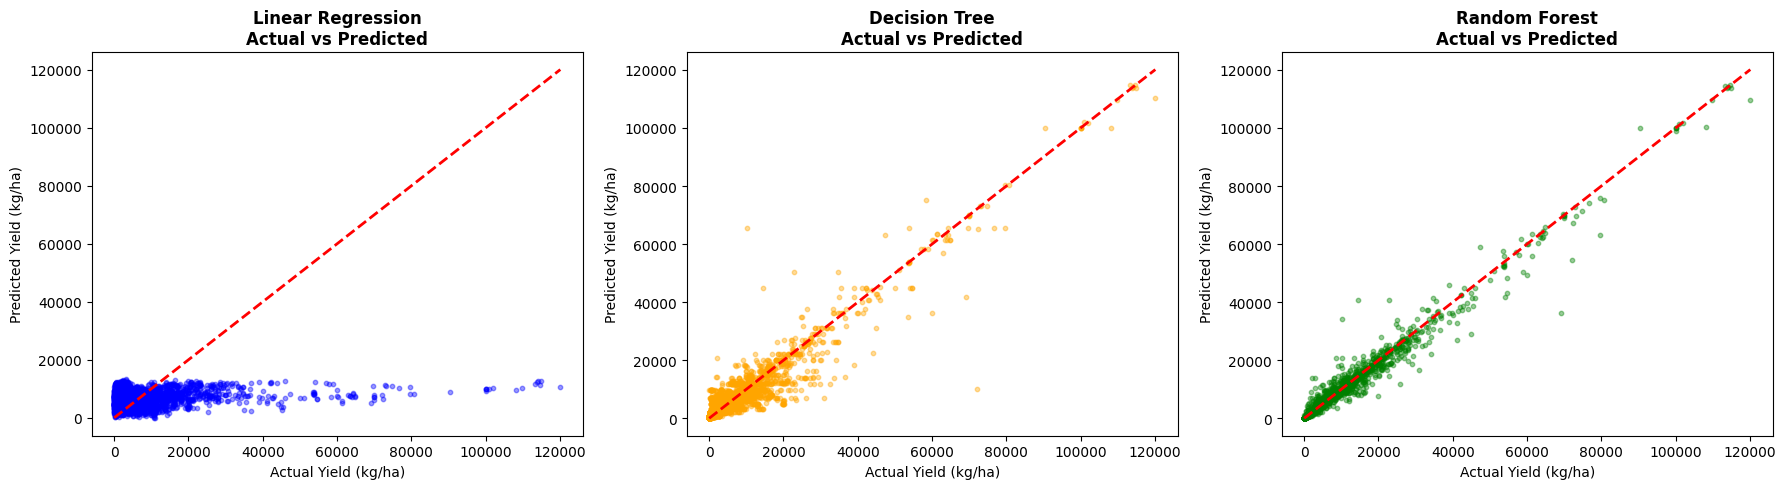

Figure saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('Linear Regression', lr_preds, 'blue'), ('Decision Tree', dt_preds, 'orange'), ('Random Forest', rf_preds, 'green')]
for ax, (name, preds, color) in zip(axes, models):
    ax.scatter(y_test, preds, color=color, alpha=0.4, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## CELL 9 - Feature Importance

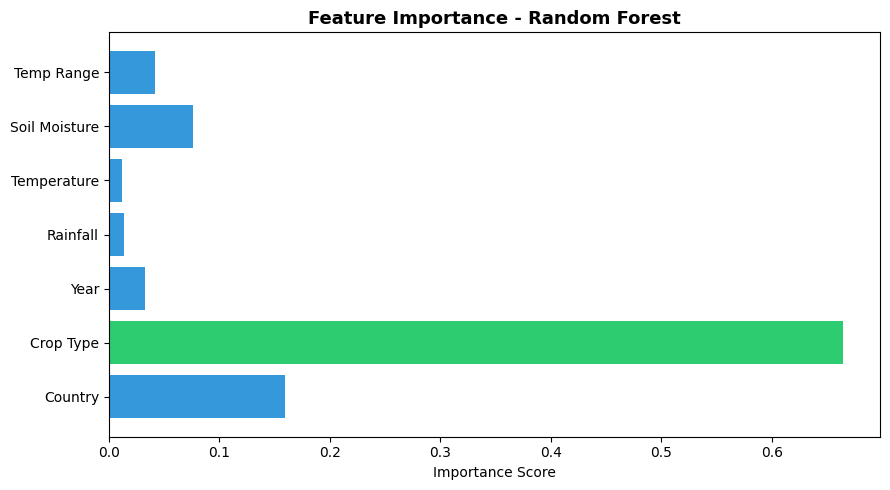

In [20]:
feature_names = ['Country','Crop Type','Year','Rainfall','Temperature','Soil Moisture','Temp Range']
importances = rf_model.feature_importances_
plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if i == importances.argmax() else '#3498db' for i in range(len(importances))]
plt.barh(feature_names, importances, color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 10 - Compare Models

In [21]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [round(lr_mae,2), round(dt_mae,2), round(rf_mae,2)],
    'RMSE': [round(lr_rmse,2), round(dt_rmse,2), round(rf_rmse,2)],
    'R2 Score': [round(lr_r2,4), round(dt_r2,4), round(rf_r2,4)]
})
print('='*60)
print('MODEL PERFORMANCE COMPARISON')
print('='*60)
print(results.to_string(index=False))
print('='*60)
print('Best Model:', results.loc[results['R2 Score'].idxmax(), 'Model'])

MODEL PERFORMANCE COMPARISON
            Model     MAE     RMSE  R2 Score
Linear Regression 6169.36 10926.32    0.0576
    Decision Tree 1770.97  3513.97    0.9025
    Random Forest  623.75  1739.70    0.9761
Best Model: Random Forest


## CELL 11 - Save All Models and Encoders

In [22]:
with open('lr_model.pkl','wb') as f: pickle.dump(lr_model, f)
with open('dt_model.pkl','wb') as f: pickle.dump(dt_model, f)
with open('rf_model.pkl','wb') as f: pickle.dump(rf_model, f)
with open('le_area.pkl','wb') as f: pickle.dump(le_area, f)
with open('le_item.pkl','wb') as f: pickle.dump(le_item, f)
print('All models saved successfully!')

All models saved successfully!
